# Figure 4. Angiotypicity, drug targeting and hormonal regulation along the cardiac vascular axis

2 panels of this figure are built below, one section each.

---

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']
import sys
sys.path[:0] = ["../src", "../figures/_lib", "../figures/Fig4"]
from hhca.paths import TABLES, OUT
print('inputs :', TABLES)
print('outputs:', OUT)

inputs : /Volumes/Storage/hhca_spatial_tables
outputs: /Users/maiia.shulman/hhca_release_out


## Fig4 h

Fig 4h — vascular marker genes, connexins, junctions and caveolins across vessel-wall compartments.

Input:
- `heart_results/vessel_caliber_markers_extended/tables/connexin_tj_pooled_matrix_11slide.csv`

Source: `figures/Fig4/panel_h.py`

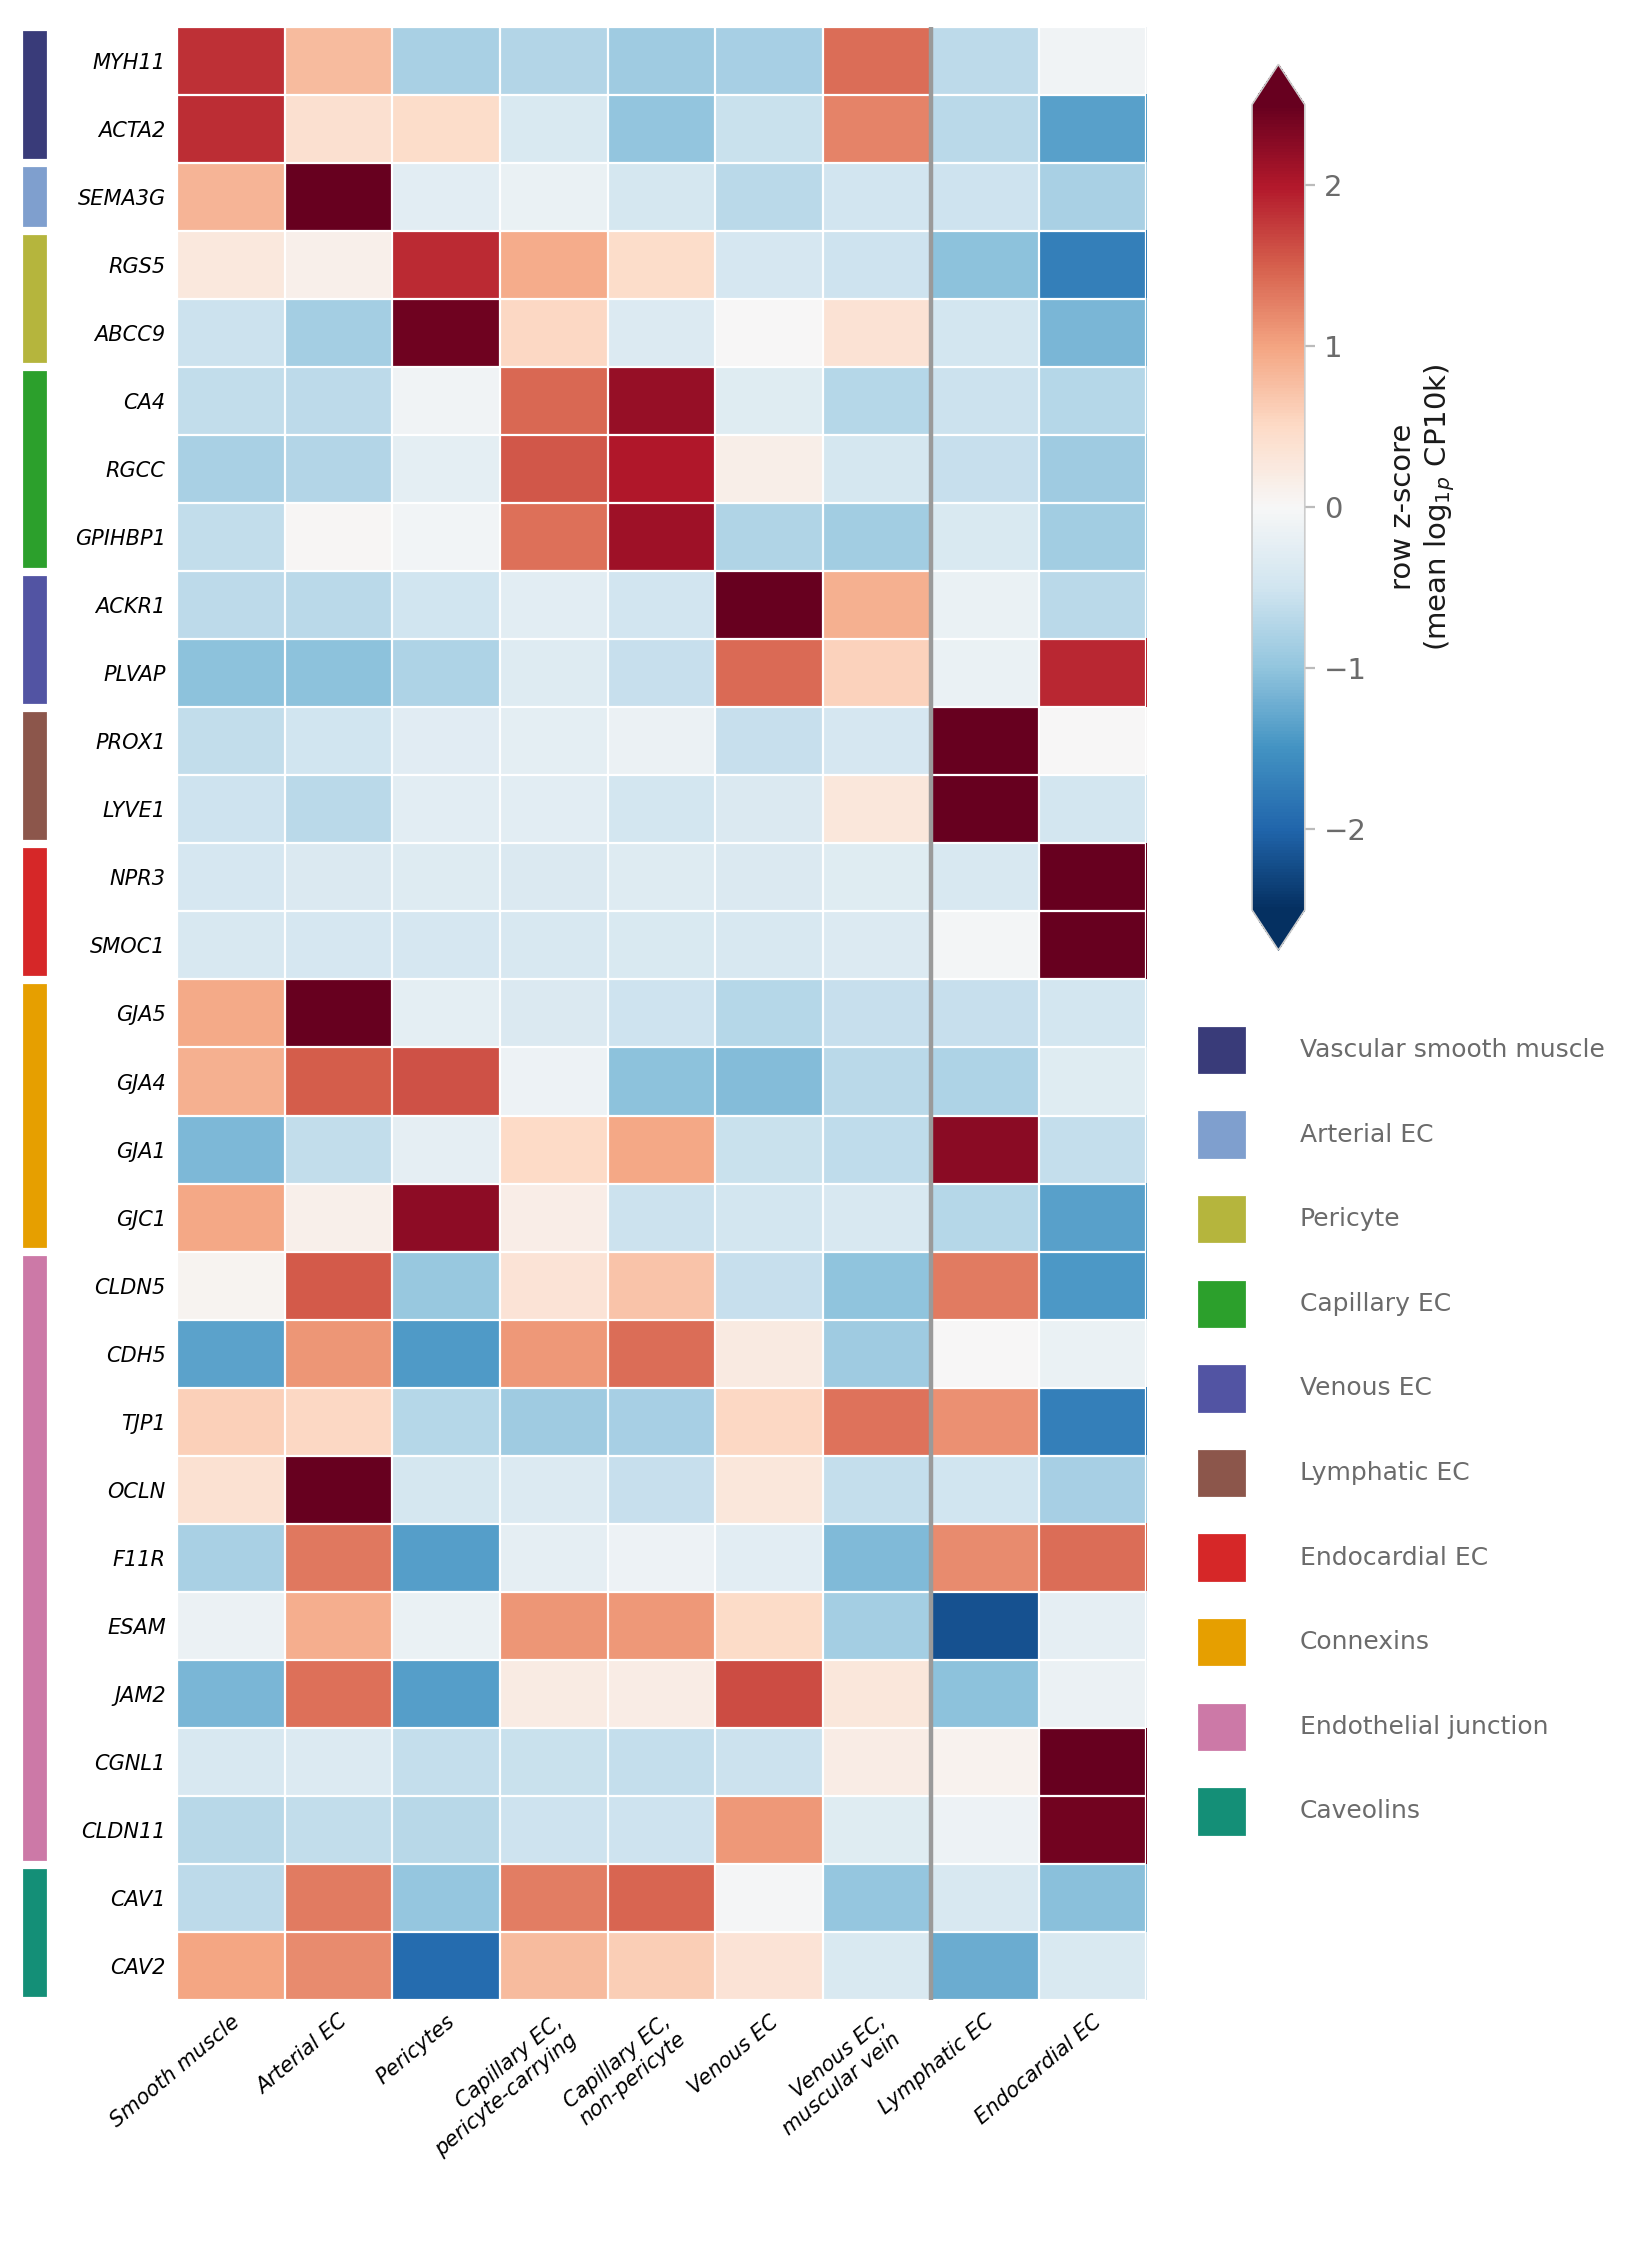

In [2]:
from hhca.paths import TABLES
from pubfig import save
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

INK, MUTE = "#1a1a1a", "#6b6b6b"
CTCOL = {"VSMC": "#393b79", "Arterial EC": "#7f9fce", "Pericyte": "#b5b53d", "Capillary EC": "#2ca02c",
         "Venous EC": "#5254a3", "Lymphatic EC": "#8c564b", "Endocardial": "#d62728",
         "Connexins": "#e69f00", "Tight junction": "#cc79a7", "Caveolins": "#148f77"}
COLS = [("Vascular Smooth Muscle cells", "Smooth muscle"), ("Arterial Endothelial cells", "Arterial EC"),
        ("Pericytes", "Pericytes"), ("Capillary EC (pericyte+)", "Capillary EC,\npericyte-carrying"),
        ("Capillary EC (pericyte-)", "Capillary EC,\nnon-pericyte"), ("Venous Endothelial cells", "Venous EC"),
        ("Venous EC (muscular vein)", "Venous EC,\nmuscular vein"), ("Lymphatic Endothelial Cells", "Lymphatic EC"),
        ("Endocardial Endothelial Cells", "Endocardial EC")]
N_CAL = 7
GROUPS = [("Vascular smooth muscle", ["MYH11", "ACTA2"], "VSMC"), ("Arterial EC", ["SEMA3G"], "Arterial EC"),
          ("Pericyte", ["RGS5", "ABCC9"], "Pericyte"), ("Capillary EC", ["CA4", "RGCC", "GPIHBP1"], "Capillary EC"),
          ("Venous EC", ["ACKR1", "PLVAP"], "Venous EC"), ("Lymphatic EC", ["PROX1", "LYVE1"], "Lymphatic EC"),
          ("Endocardial EC", ["NPR3", "SMOC1"], "Endocardial"),
          ("Connexins", ["GJA5", "GJA4", "GJA1", "GJC1"], "Connexins"),
          ("Endothelial junction", ["CLDN5", "CDH5", "TJP1", "OCLN", "F11R", "ESAM", "JAM2", "CGNL1", "CLDN11"], "Tight junction"),
          ("Caveolins", ["CAV1", "CAV2"], "Caveolins")]

tg = pd.read_csv(f"{TABLES}/heart_results/vessel_caliber_markers_extended/tables/connexin_tj_pooled_matrix_11slide.csv")
logcp = tg.pivot(index="gene", columns="type", values="logcp").reindex(columns=[c[0] for c in COLS])
GENES = [g for _, genes, _ in GROUPS for g in genes if g in logcp.index]
cp = logcp.reindex(index=GENES)
Z = cp.sub(cp.mean(axis=1), axis=0).div(cp.std(axis=1, ddof=0).replace(0, np.nan), axis=0).fillna(0.0).values
vmax = round(min(2.5, float(np.nanmax(np.abs(Z)))) + 0.05, 1)
norm, cmap = mcolors.Normalize(-vmax, vmax), plt.get_cmap("RdBu_r")

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial"],
                     "pdf.fonttype": 42, "axes.linewidth": 0.6, "text.color": INK})
nrow, ncol = len(GENES), len(COLS)
fig = plt.figure(figsize=(8.0, 11.1))
ax = fig.add_axes([0.098, 0.108, 0.606, 0.889])
ax.imshow(Z, aspect="auto", cmap=cmap, norm=norm, extent=[-0.5, ncol - 0.5, nrow - 0.5, -0.5], interpolation="nearest")
for xg in np.arange(-0.5, ncol, 1):
    ax.axvline(xg, color="white", lw=0.8)
for yg in np.arange(-0.5, nrow, 1):
    ax.axhline(yg, color="white", lw=0.8)
ax.axvline(N_CAL - 0.5, color="#9a9a9a", lw=1.6)
ax.set_xlim(-0.5, ncol - 0.5)
ax.set_ylim(nrow - 0.5, -0.5)
ax.set_xticks(range(ncol))
ax.set_xticklabels([c[1] for c in COLS], fontsize=7.5, rotation=40, ha="right", rotation_mode="anchor", style="italic")
ax.set_yticks(range(nrow))
ax.set_yticklabels(GENES, fontsize=7.5, style="italic")
ax.tick_params(length=0, pad=4)
for s in ax.spines.values():
    s.set_visible(False)
gi = 0
for _, genes, ckey in GROUPS:                       # left group colour bars
    present = [g for g in genes if g in GENES]
    ax.add_patch(Rectangle((-0.5 - 1.42, gi - 0.5 + 0.08), 0.2, len(present) - 0.16,
                           color=CTCOL[ckey], clip_on=False))
    gi += len(present)

cax = fig.add_axes([0.77, 0.581, 0.033, 0.399])   # tall colourbar, top-aligned with the heatmap
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, extend="both")
cb.set_label("row z-score\n(mean log$_1$$_p$ CP10k)", fontsize=10.5, color=INK, labelpad=8)
cb.ax.tick_params(labelsize=10.5, color="#bbbbbb", labelcolor=MUTE)
cb.outline.set_edgecolor("#cccccc")
cb.outline.set_linewidth(0.6)

key = [("Vascular smooth muscle", "VSMC"), ("Arterial EC", "Arterial EC"), ("Pericyte", "Pericyte"),
       ("Capillary EC", "Capillary EC"), ("Venous EC", "Venous EC"), ("Lymphatic EC", "Lymphatic EC"),
       ("Endocardial EC", "Endocardial"), ("Connexins", "Connexins"),
       ("Endothelial junction", "Tight junction"), ("Caveolins", "Caveolins")]
gax = fig.add_axes([0, 0, 1, 1])
gax.axis("off")
for j, (lab, ck) in enumerate(key):
    yy = 0.536 - j * 0.0381
    gax.add_patch(Rectangle((0.737, yy - 0.010), 0.028, 0.020, color=CTCOL[ck], transform=gax.transAxes))
    gax.text(0.80, yy, lab, transform=gax.transAxes, fontsize=9, color=MUTE, va="center", ha="left")
save(fig, "Fig4", "h")


## Fig4 i

Fig 4i — RAAS row z-scores across vessel types (June richness-adjusted fit).

Input:
- `heart_results/raas_corrected/raas_emm_by_gene_vessel.csv`

Source: `figures/Fig4/panel_i.py`

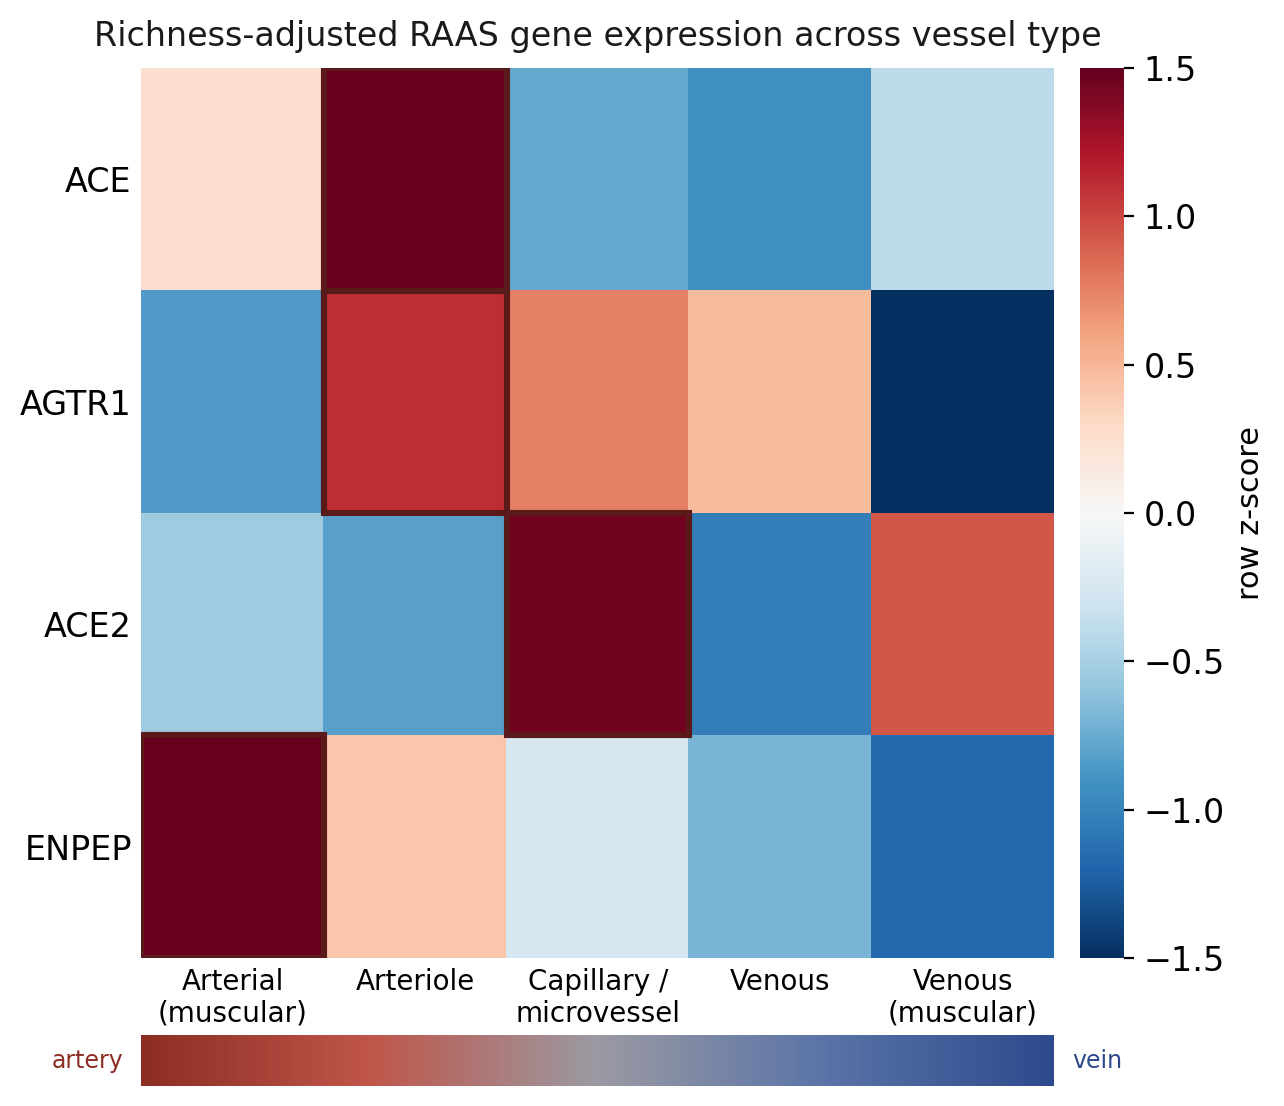

In [3]:
from hhca.paths import TABLES, OUT
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

EMM = f"{TABLES}/heart_results/raas_corrected/raas_emm_by_gene_vessel.csv"
DST = f"{OUT}/publication/Fig4"
os.makedirs(DST, exist_ok=True)

GENES = ["ACE", "AGTR1", "ACE2", "ENPEP"]
VT = ["Arterial(muscular)", "Arteriole", "Capillary/microvessel", "Venous", "Venous(muscular)"]
LAB = ["Arterial\n(muscular)", "Arteriole", "Capillary /\nmicrovessel", "Venous", "Venous\n(muscular)"]

e = pd.read_csv(EMM).pivot(index="gene", columns="vessel_type", values="emm_log1p_cp10k").loc[GENES, VT]
M = e.to_numpy(float)
Z = (M - M.mean(1, keepdims=True)) / M.std(1, ddof=0, keepdims=True)

plt.rcParams.update({"font.family": "sans-serif", "pdf.fonttype": 42})
fig = plt.figure(figsize=(1934 / 300, 1687 / 300))
ax = fig.add_axes([0.110, 0.144, 0.708, 0.791])
im = ax.imshow(Z, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
for i in range(len(GENES)):
    ax.add_patch(plt.Rectangle((int(np.argmax(Z[i])) - 0.5, i - 0.5), 1, 1, fill=False,
                               edgecolor="#5A1A1A", linewidth=2.2, zorder=5))
ax.set_xticks(range(len(VT)), LAB, fontsize=10)
ax.set_yticks(range(len(GENES)), GENES, fontsize=12)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Richness-adjusted RAAS gene expression across vessel type", fontsize=12, pad=8)

cax = fig.add_axes([0.838, 0.144, 0.034, 0.791])
cb = fig.colorbar(im, cax=cax)
cb.set_label("row z-score", fontsize=11)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=12)

gax = fig.add_axes([0.110, 0.030, 0.708, 0.045])
av = LinearSegmentedColormap.from_list("av", ["#8C2D24", "#c0564a", "#9b9aa3", "#5a74a8", "#2D4A8C"])
gax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=av)
gax.set_axis_off()
gax.text(-0.02, 0.5, "artery", transform=gax.transAxes, ha="right", va="center", fontsize=8.5, color="#8C2D24")
gax.text(1.02, 0.5, "vein", transform=gax.transAxes, ha="left", va="center", fontsize=8.5, color="#2D4A8C")

for ext in ("png", "pdf"):
    fig.savefig(f"{DST}/panel_i.{ext}", dpi=300, facecolor="white")
